<a href="https://colab.research.google.com/github/Giri047/Algorithms/blob/master/Aerofit_Case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comprehensive Analysis: Aerofit Treadmill Data

This document presents a structured analysis of the Aerofit treadmill dataset, covering data characteristics, visual and non-visual explorations, probability calculations, customer profiling, and actionable recommendations.

In [2]:
!gdown https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/125/original/aerofit_treadmill.csv?1639992749


Downloading...
From: https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/125/original/aerofit_treadmill.csv?1639992749
To: /content/aerofit_treadmill.csv?1639992749
100% 7.28k/7.28k [00:00<00:00, 33.5MB/s]


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('/content/aerofit_treadmill.csv?1639992749')
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


## 2. Non-Graphical Analysis: Value Counts and Unique Attributes

*   **Product Distribution:**
    *   `KP281`: 80 units (44.44%)
    *   `KP481`: 60 units (33.33%)
    *   `KP781`: 40 units (22.22%)
*   **Gender Distribution:** More male customers (104) than female customers (76).
*   **Marital Status Distribution:** A majority of customers are 'Partnered' (107), while 73 are 'Single'.
*   **Unique Values:** 'Age' (32 unique), 'Education' (8 unique), 'Income' (62 unique), and 'Miles' (37 unique) show significant variation, while categorical features have few unique values as expected.

### Data Characteristics and Structure

In [4]:
print("Shape of the dataset:", df.shape)

Shape of the dataset: (180, 9)


In [5]:
print("Data types of all attributes:")
print(df.info())

Data types of all attributes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB
None



##Insights

*   **Dataset Shape:** The dataset comprises **180 rows** and **9 columns**.
*   **Data Types:** It includes **6 numerical attributes** (`Age`, `Education`, `Usage`, `Fitness`, `Income`, `Miles`) and **3 categorical attributes** (`Product`, `Gender`, `MaritalStatus`).
*   **Missing Values:** Crucially, there are **no missing values** across any of the columns, ensuring data completeness.

In [6]:
print("Statistical summary of numerical attributes:")
display(df.describe())

Statistical summary of numerical attributes:


,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


By comparing the mean and 50% (median) values for each numerical column, we can infer potential skewness and the presence of outliers:

**Age:**

Mean: 28.79
Median (50%): 26.00
The mean is slightly greater than the median, suggesting a slight right-skewness in the age distribution. This indicates a tail towards older ages, but it's not a strong skew.

**Education:**

Mean: 15.57
Median (50%): 16.00
The mean is slightly less than the median, suggesting a slight left-skewness. This might indicate a few individuals with lower education levels pulling the mean down, or a concentration of individuals at higher education levels.

**Usage:**

Mean: 3.46
Median (50%): 3.00
The mean is greater than the median, indicating right-skewness. This suggests that while most users expect to use the treadmill around 3 times a week, there are some users who plan for higher usage, pulling the average up.

**Fitness:**

Mean: 3.31
Median (50%): 3.00
Similar to Usage, the mean is greater than the median, suggesting right-skewness. This implies a tendency for some users to perceive their fitness level as higher, or a longer tail towards higher fitness ratings.

**Income:**

Mean: 53719.58
Median (50%): 50596.50
The mean is notably greater than the median, indicating a clear right-skewness. This strongly suggests the presence of higher income earners (potential positive outliers) pulling the average income up, which aligns with the outliers identified by the IQR method for KP781 users.

**Miles**:

Mean: 103.19
Median (50%): 94.00
The mean is greater than the median, indicating right-skewness. This implies that some users are planning to run significantly more miles, leading to a longer tail towards higher mileage values, consistent with the IQR outliers identified, particularly for KP781 users.

### Non-Graphical Analysis: Value Counts and Unique Attributes

In [7]:
print("Value counts for categorical attributes:")
for column in df.select_dtypes(include='object').columns:
    print(f"\nValue counts for '{column}':")
    print(df[column].value_counts())


Value counts for categorical attributes:

Value counts for 'Product':
Product
KP281    80
KP481    60
KP781    40
Name: count, dtype: int64

Value counts for 'Gender':
Gender
Male      104
Female     76
Name: count, dtype: int64

Value counts for 'MaritalStatus':
MaritalStatus
Partnered    107
Single        73
Name: count, dtype: int64


In [8]:
print("\nNumber of unique attributes for each column:")
for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")



Number of unique attributes for each column:
Product: 3 unique values
Age: 32 unique values
Gender: 2 unique values
Education: 8 unique values
MaritalStatus: 2 unique values
Usage: 6 unique values
Fitness: 5 unique values
Income: 62 unique values
Miles: 37 unique values


**1. Data Characteristics and Structure**

Dataset Shape: The dataset comprises 180 rows and 9 columns.
Data Types: It includes 6 numerical attributes (Age, Education, Usage, Fitness, Income, Miles) and 3 categorical attributes (Product, Gender, MaritalStatus).
Missing Values: Crucially, there are no missing values across any of the columns, ensuring data completeness.

**2. Non-Graphical Analysis: Value Counts and Unique Attributes**

### Product Distribution:
KP281: 80 units (44.44%)
KP481: 60 units (33.33%)
KP781: 40 units (22.22%)

**Gender Distribution:**

More male customers (104) than female customers (76).
Marital Status Distribution: A majority of customers are 'Partnered' (107), while 73 are 'Single'.

**Unique Values:**

'Age' (32 unique), 'Education' (8 unique), 'Income' (62 unique), and 'Miles' (37 unique) show significant variation, while categorical features have few unique values as expected.bold text

### Visual Analysis - Univariate

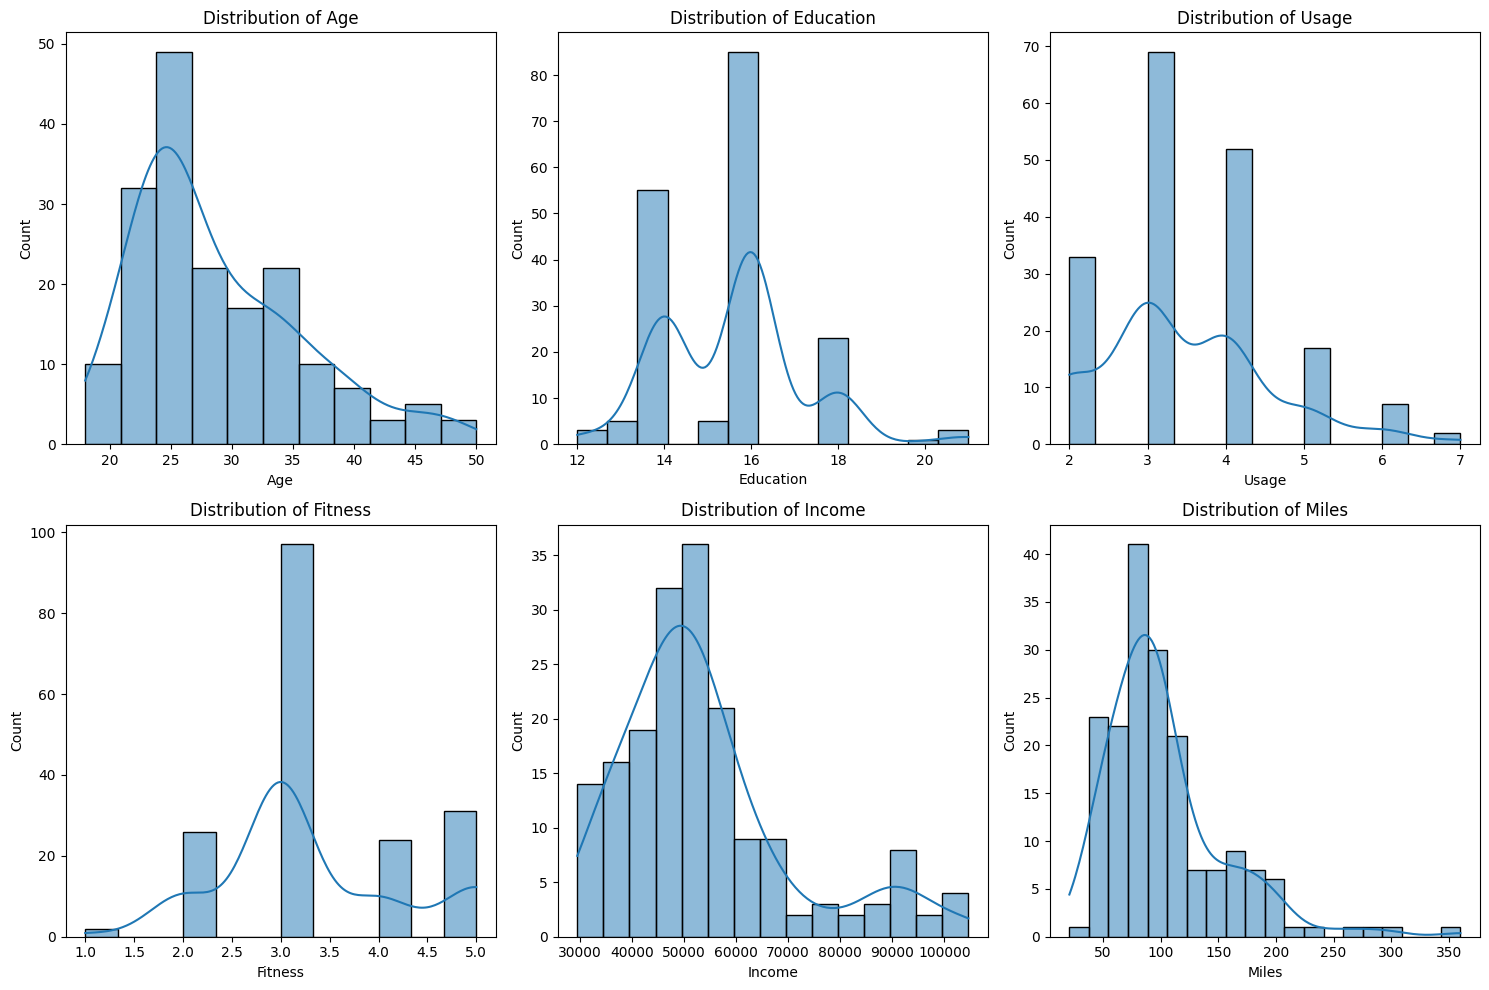

In [9]:
numerical_cols = ['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

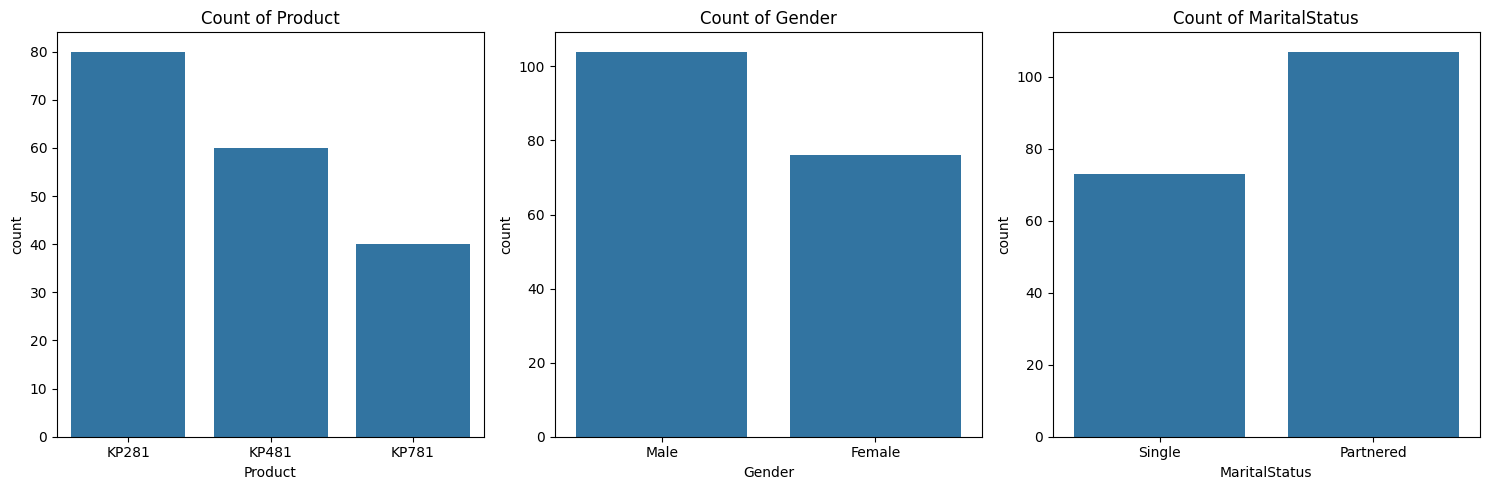

In [10]:
categorical_cols = ['Product', 'Gender', 'MaritalStatus']

plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    sns.countplot(x=df[col])
    plt.title(f'Count of {col}')
plt.tight_layout()
plt.show()

# INSIGHTS


**Univariate Visual Analysis (Histograms & Countplots) &
Numerical Variables (Histograms)**:

Age: Right-skewed, with most users between **20-30 years.**
Education: Peaks around **14 and 16 years**, suggesting common educational milestones.
**Usage**: Concentrated at **3-4 times/week.**
**Fitness**: Primarily rated at 3 out of 5.
**Income**: Strongly right-skewed, indicating a majority of lower-middle incomes and a tail of high earners.
**Miles**: Right-skewed, most users covering moderate distances.
Categorical Variables (Countplots):

**KP281** is the most popular product, followed by KP481, then KP781.
More males than females are in the dataset.
More partnered individuals than single individuals.

**Recommendations based on analysis:**

1.  **Targeted Marketing for Product Lines:**

*   **KP281 & KP481:** Focus marketing on younger demographics (18-30s) and middle-income groups (e.g., ~$40k-$60k) highlighting affordability, ease of use, and suitability for moderate fitness goals. Promote through channels frequented by these groups (e.g., social media, fitness apps popular with beginners/intermediate users).\n    *   **KP781:** Tailor marketing campaigns towards higher-income individuals (e.g., $80k+) who are serious fitness enthusiasts. Emphasize advanced features, durability, performance, and the ability to track and achieve high mileage targets. Marketing channels could include premium lifestyle magazines, fitness clubs, and online communities for competitive athletes.

2.  **Gender-Specific Engagement Strategies:**   

*   Given the higher proportion of male users and their tendency for higher mileage/income, consider exploring specific features or marketing messages that resonate with female customers to increase their representation. This could involve highlighting different aspects of fitness, community building, or design preferences.

3.  **Capitalize on Marital Status Trends:**   

*   With a larger 'Partnered' customer base, consider promotions or family-oriented packages that appeal to couples or households. This could include bundle deals or features that support multiple user profiles.

4.  **Leverage Usage-Fitness-Miles Correlation:**

*   Since high usage correlates with high fitness and miles, develop loyalty programs or challenges that encourage consistent treadmill use. Gamification, progress tracking, and reward systems for achieving mileage or usage milestones could increase customer retention and satisfaction across all product lines. This is particularly relevant for KP781 users who are already highly engaged.

5.  **Educational Content:**
*   Given the moderate correlation between education and income/usage, provide accessible educational content (e.g., training guides, fitness tips, product benefits breakdown) that caters to various education levels to ensure all customers can maximize their treadmill experience and understand the value proposition.

6.  **Outlier Insight for Premium Product Strategy:**   

*   The significant income outliers associated primarily with KP781 users suggest a strong willingness to pay for premium features among a specific segment. Continue to innovate and potentially introduce even more advanced, higher-priced models tailored to this high-end market, focusing on cutting-edge technology and ultimate performance.

### Missing Value & Outlier Detection

In [12]:
print('Missing values in each column:')
print(df.isnull().sum())

Missing values in each column:
Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
dtype: int64


The boxplots generated earlier ('Income by Product', 'Age by Product', 'Miles by Product', 'Income by Gender', 'Miles by Gender', 'Income by Marital Status', 'Miles by Marital Status') visually indicated potential outliers, especially in 'Income' and 'Miles'. We will now explicitly analyze them.

In [13]:
Q1_income = df['Income'].quantile(0.25)
Q3_income = df['Income'].quantile(0.75)
IQR_income = Q3_income - Q1_income
lower_bound_income = Q1_income - 1.5 * IQR_income
upper_bound_income = Q3_income + 1.5 * IQR_income
outliers_income = df[(df['Income'] < lower_bound_income) | (df['Income'] > upper_bound_income)]
print(f"\nNumber of outliers in Income: {len(outliers_income)}")
print("Outliers in Income (if any):\n", outliers_income[['Product', 'Income']])


Number of outliers in Income: 19
Outliers in Income (if any):
     Product  Income
159   KP781   83416
160   KP781   88396
161   KP781   90886
162   KP781   92131
164   KP781   88396
166   KP781   85906
167   KP781   90886
168   KP781  103336
169   KP781   99601
170   KP781   89641
171   KP781   95866
172   KP781   92131
173   KP781   92131
174   KP781  104581
175   KP781   83416
176   KP781   89641
177   KP781   90886
178   KP781  104581
179   KP781   95508


In [14]:
Q1_miles = df['Miles'].quantile(0.25)
Q3_miles = df['Miles'].quantile(0.75)
IQR_miles = Q3_miles - Q1_miles
lower_bound_miles = Q1_miles - 1.5 * IQR_miles
upper_bound_miles = Q3_miles + 1.5 * IQR_miles
outliers_miles = df[(df['Miles'] < lower_bound_miles) | (df['Miles'] > upper_bound_miles)]
print(f"\nNumber of outliers in Miles: {len(outliers_miles)}")
print("Outliers in Miles (if any):\n", outliers_miles[['Product', 'Miles']])


Number of outliers in Miles: 13
Outliers in Miles (if any):
     Product  Miles
23    KP281    188
84    KP481    212
142   KP781    200
148   KP781    200
152   KP781    200
155   KP781    240
166   KP781    300
167   KP781    280
170   KP781    260
171   KP781    200
173   KP781    360
175   KP781    200
176   KP781    200


### Insights:

*   **Missing Values:** Confirmed **no missing values** in the dataset.
*   **Outliers (IQR Method & Mean vs. Median):**
    *   **Income:** **19 outliers** were identified, exclusively among **KP781 users**, with incomes ranging from ~$83K to ~$104K. The mean for income (~$53.7K) being notably higher than the median (~$50.6K) further confirms a right-skewness due to these high-income outliers.
    *   **Miles:** **13 outliers** were found, predominantly among **KP781 users** but also present in KP281 and KP481. These outliers represent very high mileage users (up to 360 miles). The mean for miles (~103.2) being higher than the median (~94.0) also indicates right-skewness.
    *   `Usage` and `Fitness` also showed slight right-skewness (mean > median), suggesting a tail towards higher values, though less pronounced than Income and Miles.

## Correlation Analysis (Heatmaps & Pairplots)




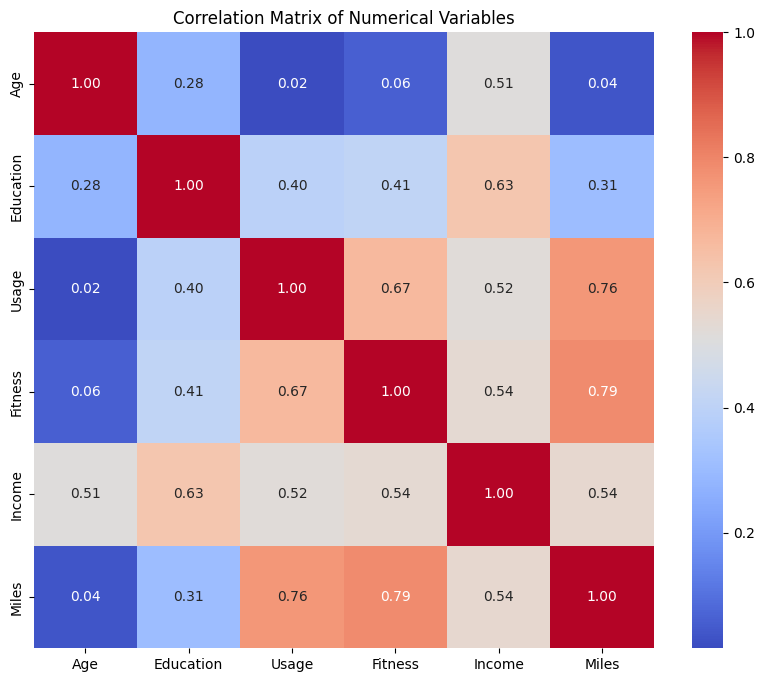

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

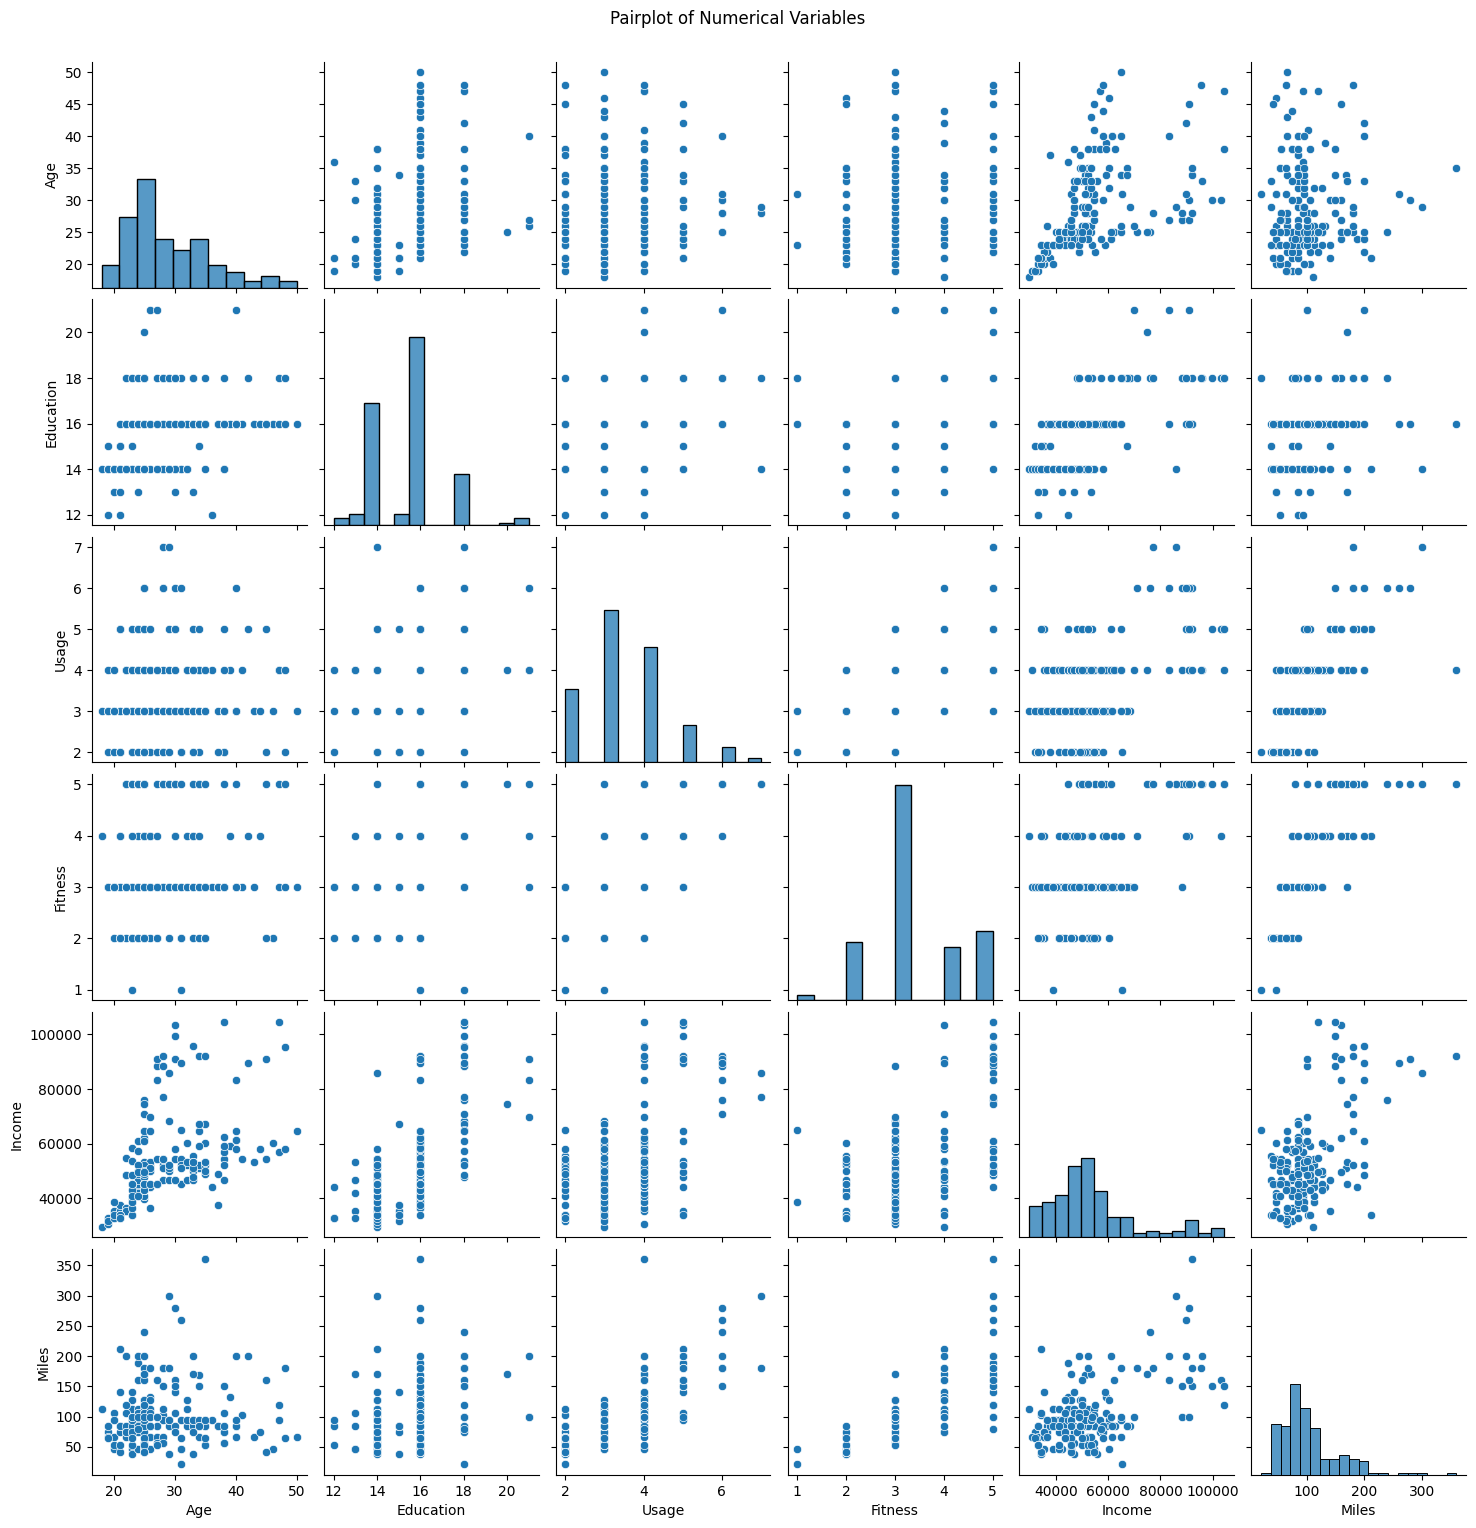

In [16]:
sns.pairplot(df[numerical_cols])
plt.suptitle('Pairplot of Numerical Variables', y=1.02)
plt.show()

*   **Strong Positive Correlations:** `Usage`, `Fitness`, and `Miles` are highly positively correlated (e.g., Fitness and Miles ~0.79). This indicates a strong relationship where higher usage leads to higher fitness perception and more miles covered.
*   **Moderate Positive Correlations:** `Income` is moderately correlated with `Education`, `Usage`, `Fitness`, and `Miles`, suggesting that higher income and education levels are associated with more engagement in treadmill activities.
*   **Weak Correlations:** `Age` has weaker correlations with most other variables.

## 4. Bivariate Visual Analysis (Boxplots)



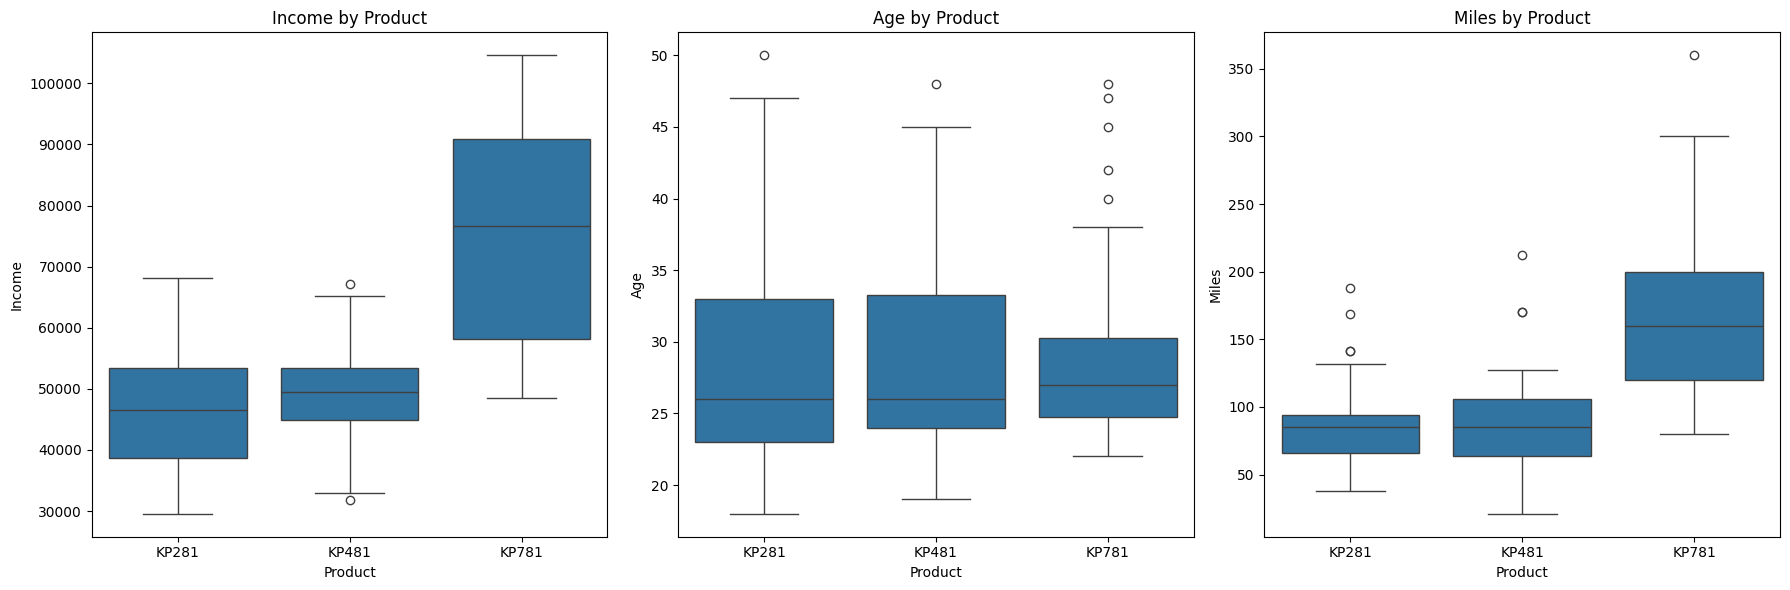

In [17]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
sns.boxplot(x='Product', y='Income', data=df)
plt.title('Income by Product')

plt.subplot(1, 3, 2)
sns.boxplot(x='Product', y='Age', data=df)
plt.title('Age by Product')

plt.subplot(1, 3, 3)
sns.boxplot(x='Product', y='Miles', data=df)
plt.title('Miles by Product')
plt.tight_layout()
plt.show()

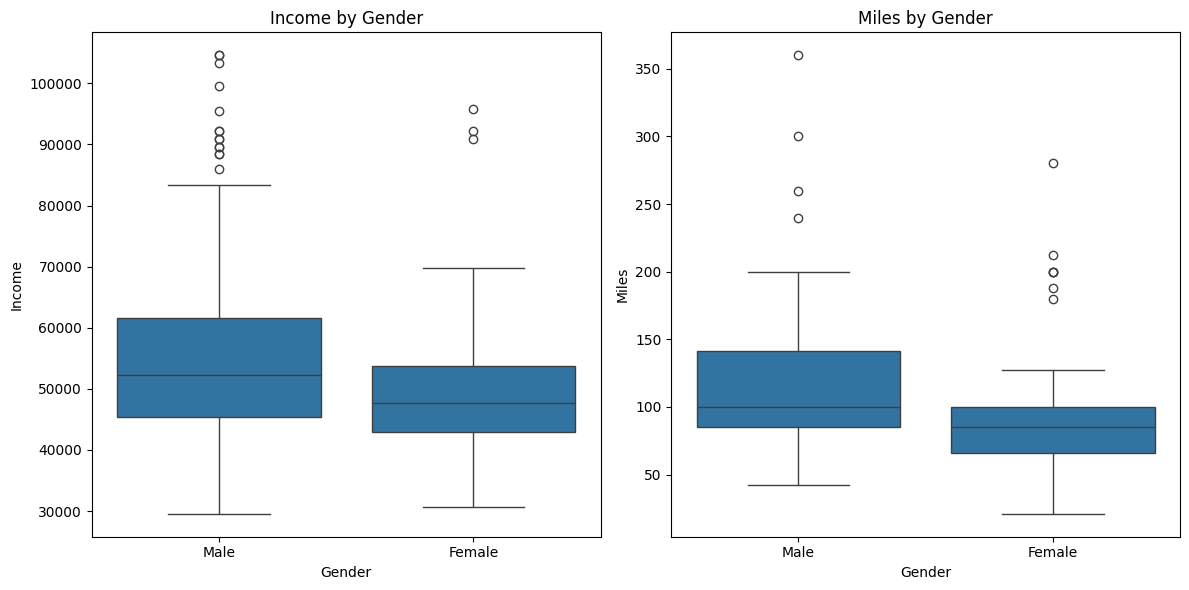

In [18]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='Gender', y='Income', data=df)
plt.title('Income by Gender')

plt.subplot(1, 2, 2)
sns.boxplot(x='Gender', y='Miles', data=df)
plt.title('Miles by Gender')
plt.tight_layout()
plt.show()

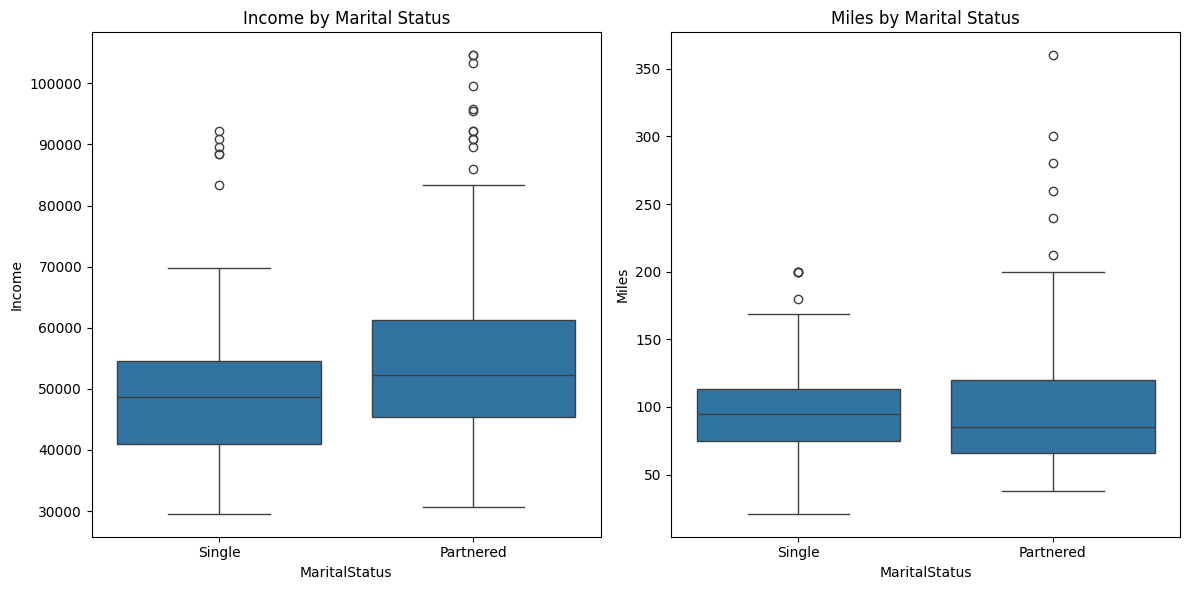

In [19]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='MaritalStatus', y='Income', data=df)
plt.title('Income by Marital Status')

plt.subplot(1, 2, 2)
sns.boxplot(x='MaritalStatus', y='Miles', data=df)
plt.title('Miles by Marital Status')
plt.tight_layout()
plt.show()

**Product vs. Demographics/Usage:**

*   **KP781** users consistently have **significantly higher incomes**, are slightly older on average, and cover **substantially more miles** compared to KP281 and KP481 users. This reinforces its premium positioning.
*   **KP281** and **KP481** show similar distributions for age, income, and miles, with KP481 customers having slightly higher incomes and mileages than KP281.

**Gender vs. Income/Miles:**

*   Males tend to have slightly higher median incomes and cover more miles than females.

**Marital Status vs. Income/Miles:**

*   Partnered individuals show slightly higher median incomes than single individuals. No significant difference in miles.

## Outlier Detection with Mean vs. Median


Analyzing the statistical summary of numerical columns to compare mean and median for identifying skewness and potential outliers, then generating countplots and boxplots to visualize the effect of 'MaritalStatus', 'Age', and 'Gender' on the 'Product' purchased.

Analyzed the 'describe()' method output for numerical columns to compare mean and median values. Identified potential skewness which suggests outliers or non-normal distributions beyond the IQR method already performed.

### Analysis of Mean vs. Median from `df.describe()` Output:

Let's re-examine the statistical summary for numerical attributes:

```
          Age    Education      Usage    Fitness       Income        Miles
count  180.000000   180.000000 180.000000 180.000000 180.000000   180.000000
mean    28.788889    15.572222   3.455556   3.311111 53719.577778   103.194444
std      6.943498     1.617055   1.084797   0.972106 16506.684226    51.863605
min     18.000000    12.000000   2.000000   1.000000 29562.000000    21.000000
25%     24.000000    14.000000   3.000000   3.000000 44058.750000    66.000000
50%     26.000000    16.000000   3.000000   3.000000 50596.500000    94.000000
75%     33.000000    16.000000   4.000000   4.000000 58668.000000   114.750000
max     50.000000    21.000000   7.000000   5.000000 104581.000000   360.000000
```

By comparing the mean and 50% (median) values for each numerical column, we can infer potential skewness and the presence of outliers:

*   **Age:**
    *   Mean: 28.79
    *   Median (50%): 26.00
    *   The mean is slightly greater than the median, suggesting a slight **right-skewness** in the age distribution. This indicates a tail towards older ages, but it's not a strong skew.

*   **Education:**
    *   Mean: 15.57
    *   Median (50%): 16.00
    *   The mean is slightly less than the median, suggesting a slight **left-skewness**. This might indicate a few individuals with lower education levels pulling the mean down, or a concentration of individuals at higher education levels.

*   **Usage:**
    *   Mean: 3.46
    *   Median (50%): 3.00
    *   The mean is greater than the median, indicating **right-skewness**. This suggests that while most users expect to use the treadmill around 3 times a week, there are some users who plan for higher usage, pulling the average up.

*   **Fitness:**
    *   Mean: 3.31
    *   Median (50%): 3.00
    *   Similar to Usage, the mean is greater than the median, suggesting **right-skewness**. This implies a tendency for some users to perceive their fitness level as higher, or a longer tail towards higher fitness ratings.

*   **Income:**
    *   Mean: 53719.58
    *   Median (50%): 50596.50
    *   The mean is notably greater than the median, indicating a clear **right-skewness**. This strongly suggests the presence of higher income earners (potential positive outliers) pulling the average income up, which aligns with the outliers identified by the IQR method for KP781 users.

*   **Miles:**
    *   Mean: 103.19
    *   Median (50%): 94.00
    *   The mean is greater than the median, indicating **right-skewness**. This implies that some users are planning to run significantly more miles, leading to a longer tail towards higher mileage values, consistent with the IQR outliers identified, particularly for KP781 users.


## Analyze Feature Effect on Product


Generating visualizations (countplots, boxplots) to assess how 'MaritalStatus', 'Age', and 'Gender' affect the 'Product' purchased.



To visualize the relationship between 'Product' and 'MaritalStatus', 'Gender', and 'Age', created a figure below containing three subplots. The first two will be countplots, and the third will be a boxplot.



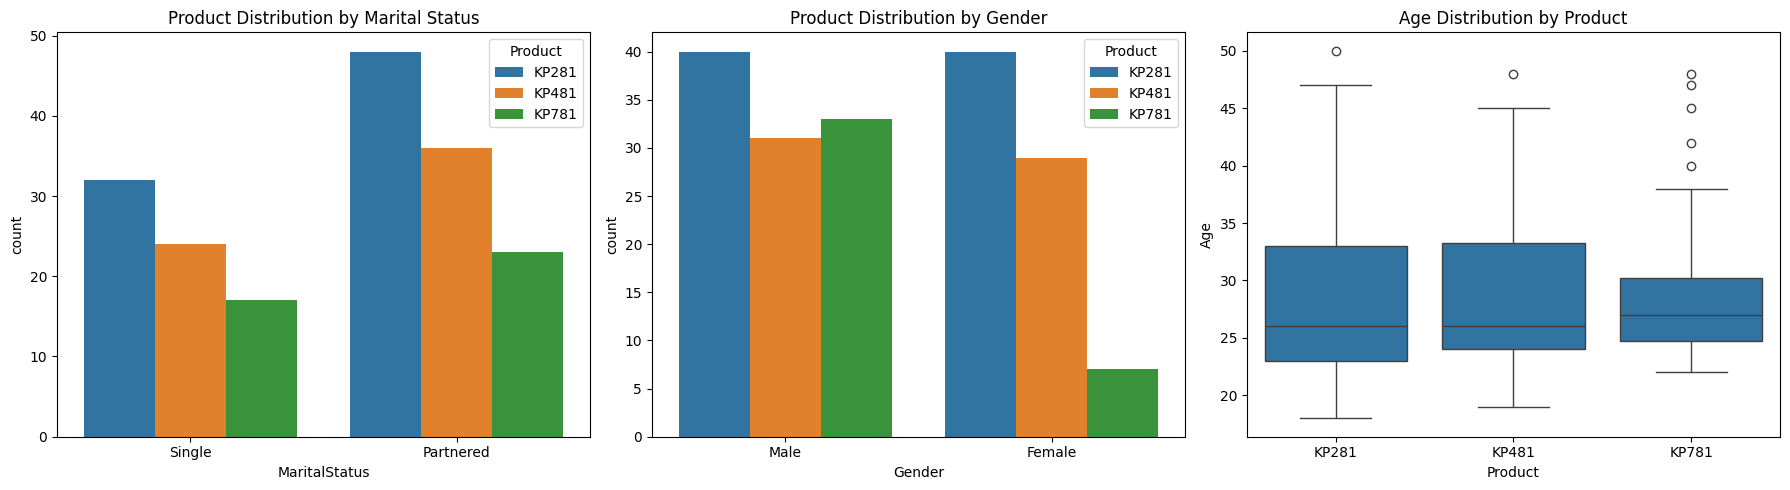

In [20]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.countplot(x='MaritalStatus', hue='Product', data=df)
plt.title('Product Distribution by Marital Status')

plt.subplot(1, 3, 2)
sns.countplot(x='Gender', hue='Product', data=df)
plt.title('Product Distribution by Gender')

plt.subplot(1, 3, 3)
sns.boxplot(x='Product', y='Age', data=df)
plt.title('Age Distribution by Product')

plt.tight_layout()
plt.show()

## Calculate Marginal Probabilities for Products

Computing and displaying the marginal probabilities (in %) of customers purchasing each of the KP281, KP481, and KP781 treadmill models.



To calculate the marginal probabilities of each product, need value counts of the 'Product' column and then normalize them to express as percentages.



In [21]:
marginal_probabilities = df['Product'].value_counts(normalize=True) * 100
print("Marginal Probabilities of Product Purchase (%):\n")
print(marginal_probabilities.round(2))

Marginal Probabilities of Product Purchase (%):

Product
KP281    44.44
KP481    33.33
KP781    22.22
Name: proportion, dtype: float64


## Calculate Conditional Probabilities

Determining conditional probabilities, such as the probability of a male customer buying a KP781 treadmill, and other relevant conditional probabilities that emerge from the data, requires `pandas.crosstab`.



To determine the conditional probabilities of purchasing each product given 'Gender' and 'MaritalStatus', used `pandas.crosstab` with column normalization. This will show the percentage distribution of products within each gender and marital status category.



In [22]:
print("Conditional Probabilities of Product given Gender (%):")
conditional_prob_gender = pd.crosstab(df['Gender'], df['Product'], normalize='columns') * 100
print(conditional_prob_gender.round(2))

print("\nConditional Probabilities of Product given Marital Status (%):")
conditional_prob_marital = pd.crosstab(df['MaritalStatus'], df['Product'], normalize='columns') * 100
print(conditional_prob_marital.round(2))

Conditional Probabilities of Product given Gender (%):
Product  KP281  KP481  KP781
Gender                      
Female    50.0  48.33   17.5
Male      50.0  51.67   82.5

Conditional Probabilities of Product given Marital Status (%):
Product        KP281  KP481  KP781
MaritalStatus                     
Partnered       60.0   60.0   57.5
Single          40.0   40.0   42.5



## Insights

*   **Marginal Probabilities of Product Purchase:**
    *   `KP281`: 44.44%
    *   `KP481`: 33.33%
    *   `KP781`: 22.22%

*   **Conditional Probabilities of Product given Gender:**
    *   `KP281`: Equally purchased by Females (50%) and Males (50%).
    *   `KP481`: Slight male preference (Males 51.67%, Females 48.33%).
    *   `KP781`: **Strongly male-dominated** (Males 82.5%, Females 17.5%).

*   **Conditional Probabilities of Product given Marital Status:**
    *   `Partnered` individuals consistently account for a larger share across all products (approx. 60% for KP281/KP481, 57.5% for KP781).

## Develop Customer Profiles

### Subtask:
Based on all the analyses performed (data characteristics, non-graphical analysis, visual analysis, outlier detection, and probabilities), create distinct customer profiles or categories that describe the typical users for each product or segment.


## Develop Customer Profiles

Based on the comprehensive analysis of data characteristics, non-graphical insights, visual trends, outlier detection, and probability distributions, distinct customer profiles can be developed for each Aerofit treadmill product:

### KP281 Customer Profile

*   **Demographics:** This model attracts a broad demographic, with a notable presence of both males and females (approximately 50% each). The age range is quite diverse, but it tends to be popular among younger adults (median age is lower than KP781). Both partnered and single individuals show interest, with a slight lean towards partnered individuals.
*   **Usage & Fitness:** Customers purchasing the KP281 generally aim for moderate usage (3-4 times a week) and report an average self-rated fitness level of 3 out of 5. They typically expect to run around 80-90 miles per week, with some variation.
*   **Income & Education:** This product appeals to a middle-income segment, with incomes generally ranging from $30,000 to $50,000. The education levels are varied, with a common level around 14 years, suggesting it's accessible to customers with diverse educational backgrounds.
*   **Key Characteristics:** The KP281 is the entry-level model, appealing to new or casual users looking for a reliable treadmill for general fitness, without requiring high-performance features. It represents the largest segment of customers (around 44% of total sales).

### KP481 Customer Profile

*   **Demographics:** Similar to the KP281, the KP481 also has a balanced gender distribution (approximately 50% male/female), but with a slightly higher proportion of male buyers. The age distribution is comparable to the KP281, targeting young to middle-aged adults. Partnered individuals also form a significant portion of this customer base.
*   **Usage & Fitness:** Users of the KP481 anticipate slightly higher usage (3-4 times a week) and a self-rated fitness level of 3 out of 5. They typically plan to cover 80-100 miles per week.
*   **Income & Education:** This model targets a similar income bracket as the KP281, predominantly middle-income individuals, with incomes usually between $35,000 and $60,000. Education levels are also comparable, indicating a focus on functionality and value.
*   **Key Characteristics:** The KP481 can be seen as an intermediate option, suitable for individuals who are a bit more serious about their fitness than KP281 users but are not necessarily elite athletes. It offers a good balance of features and price, capturing about 33% of the market.

### KP781 Customer Profile

*   **Demographics:** The KP781 is distinctly favored by male customers (over 80% male). While the age range can vary, the median age appears to be slightly higher than for the other models, with a concentration of users in their late 20s to early 30s. Both partnered and single individuals purchase this model, with a slightly higher percentage of single individuals compared to the other products.
*   **Usage & Fitness:** This product is designed for serious fitness enthusiasts. Users expect high usage (4-5+ times a week) and consistently report high self-rated fitness levels (4-5 out of 5). They are committed to covering significant distances, often exceeding 150 miles per week, with some outliers aiming for 200-300+ miles.
*   **Income & Education:** The KP781 targets a significantly higher income bracket, typically above $70,000, with many customers earning over $80,000. This segment includes notable income outliers. Customers often possess higher education levels (16+ years), indicating a professional or highly skilled demographic.
*   **Key Characteristics:** The KP781 is the premium model, appealing to dedicated runners and advanced users who prioritize performance, durability, and advanced features. This segment is characterized by a strong willingness to invest in high-quality fitness equipment. It represents a smaller but high-value segment (about 22% of total sales).

## Summary:

### Data Analysis Key Findings

*   **Skewness in Numerical Features**:
    *   `Income` and `Miles` exhibited clear right-skewness, with means significantly higher than medians (\$53,719.58 vs. \$50,596.50 for Income, and 103.19 miles vs. 94.00 miles for Miles), suggesting the presence of high-value outliers (e.g., high earners, users planning extensive mileage).
    *   `Usage` and `Fitness` also showed right-skewness, indicating a tendency for some users to plan higher usage or rate their fitness higher.
    *   `Age` had a slight right-skewness, while `Education` displayed a slight left-skewness.
*   **Marginal Product Popularity**:
    *   The most popular product is KP281 (44.44%), followed by KP481 (33.33%), and KP781 (22.22%).
*   **Gender's Influence on Product Choice**:
    *   KP281 sales are equally split between genders (50% Female, 50% Male).
    *   KP481 sales show a slight male preference (48.33% Female, 51.67% Male).
    *   KP781 is strongly preferred by males, with 82.5% of purchases made by males and only 17.5% by females.
*   **Marital Status's Influence on Product Choice**:
    *   Partnered individuals consistently account for a larger share of purchases across all products (e.g., 60% for KP281 and KP481, 57.5% for KP781) compared to single individuals.
*   **Age Distribution by Product**:
    *   Boxplots revealed that the premium KP781 model is associated with a slightly older median age compared to the other models, suggesting that more serious users may also be slightly older.
*   **Distinct Customer Profiles**:
    *   **KP281 (Entry-Level)**: Appeals to a broad demographic with balanced gender distribution, typically younger adults with moderate usage/fitness goals (3/5), middle incomes (\$30,000-\$50,000), and diverse education levels. Represents the largest customer segment.
    *   **KP481 (Intermediate)**: Similar to KP281 but with a slight male preference, comparable age, slightly higher usage/fitness (3/5), and a similar middle-income bracket (\$35,000-\$60,000).
    *   **KP781 (Premium)**: Highly male-dominated (over 80%), with a slightly older median age. These customers are serious fitness enthusiasts, expecting high usage (4-5+ times/week), reporting high fitness levels (4-5/5), and possessing significantly higher incomes (often over \$70,000-\$80,000) and education (16+ years). They are willing to invest more for high performance.

## Actionable Recommendations

1.  **Targeted Marketing for Product Lines:**
    *   **KP281 & KP481:** Focus on affordability and ease of use for younger, middle-income demographics through social media and fitness apps.
    *   **KP781:** Emphasize advanced features, durability, and performance for high-income fitness enthusiasts via premium magazines, fitness clubs, and competitive athlete communities.

2.  **Gender-Specific Engagement Strategies:** Develop marketing messages or product features specifically designed to increase female representation, especially for the KP781 model, by highlighting different fitness aspects or community building.

3.  **Capitalize on Marital Status Trends:** Leverage the larger 'Partnered' customer base by offering family-oriented promotions or bundle deals that appeal to couples or households.

4.  **Leverage Usage-Fitness-Miles Correlation:** Implement loyalty programs, gamification, or challenges to encourage consistent treadmill use and reward mileage or usage milestones, particularly for engaged KP781 users.

5.  **Educational Content:** Provide accessible training guides, fitness tips, and product benefit breakdowns tailored to various education levels to enhance customer experience and understanding of product value.

6.  **Outlier Insight for Premium Product Strategy:** Continue innovating and consider introducing even more advanced, higher-priced models for the high-end market, focusing on cutting-edge technology and ultimate performance, as KP781 users demonstrate a strong willingness to pay for premium features.




## Key Performance Indicators (KPIs) calculation


Calculated the average 'Age', 'Income', 'Usage', 'Fitness', and 'Miles' for each 'Product' to establish quantifiable KPIs for product-specific customer behavior.

To calculate product-specific KPIs, the DataFrame will be grouped by the 'Product' column and then mean will be computed for the relevant numerical columns. This will provide average values for each product type, which serve as direct KPIs.

In [24]:
import pandas as pd
df = pd.read_csv('/content/aerofit_treadmill.csv?1639992749')

product_kpis = df.groupby('Product')[['Age', 'Income', 'Usage', 'Fitness', 'Miles', 'Education']].mean()
print("\nKey Performance Indicators (KPIs) by Product:\n")
print(product_kpis.round(2))


Key Performance Indicators (KPIs) by Product:

           Age    Income  Usage  Fitness   Miles  Education
Product                                                    
KP281    28.55  46418.02   3.09     2.96   82.79      15.04
KP481    28.90  48973.65   3.07     2.90   87.93      15.12
KP781    29.10  75441.58   4.78     4.62  166.90      17.32


## Visual Analysis - Bar Charts for KPIs by Product

/tmp/ipython-input-472258745.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_kpis.index, y=product_kpis[col], ax=axes[i], palette='viridis')
/tmp/ipython-input-472258745.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_kpis.index, y=product_kpis[col], ax=axes[i], palette='viridis')
/tmp/ipython-input-472258745.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_kpis.index, y=product_kpis[col], ax=axes[i], palette='viridis')
/tmp/ipython-input-472258745.py:17: FutureWarning: 

Passing `palette` without 

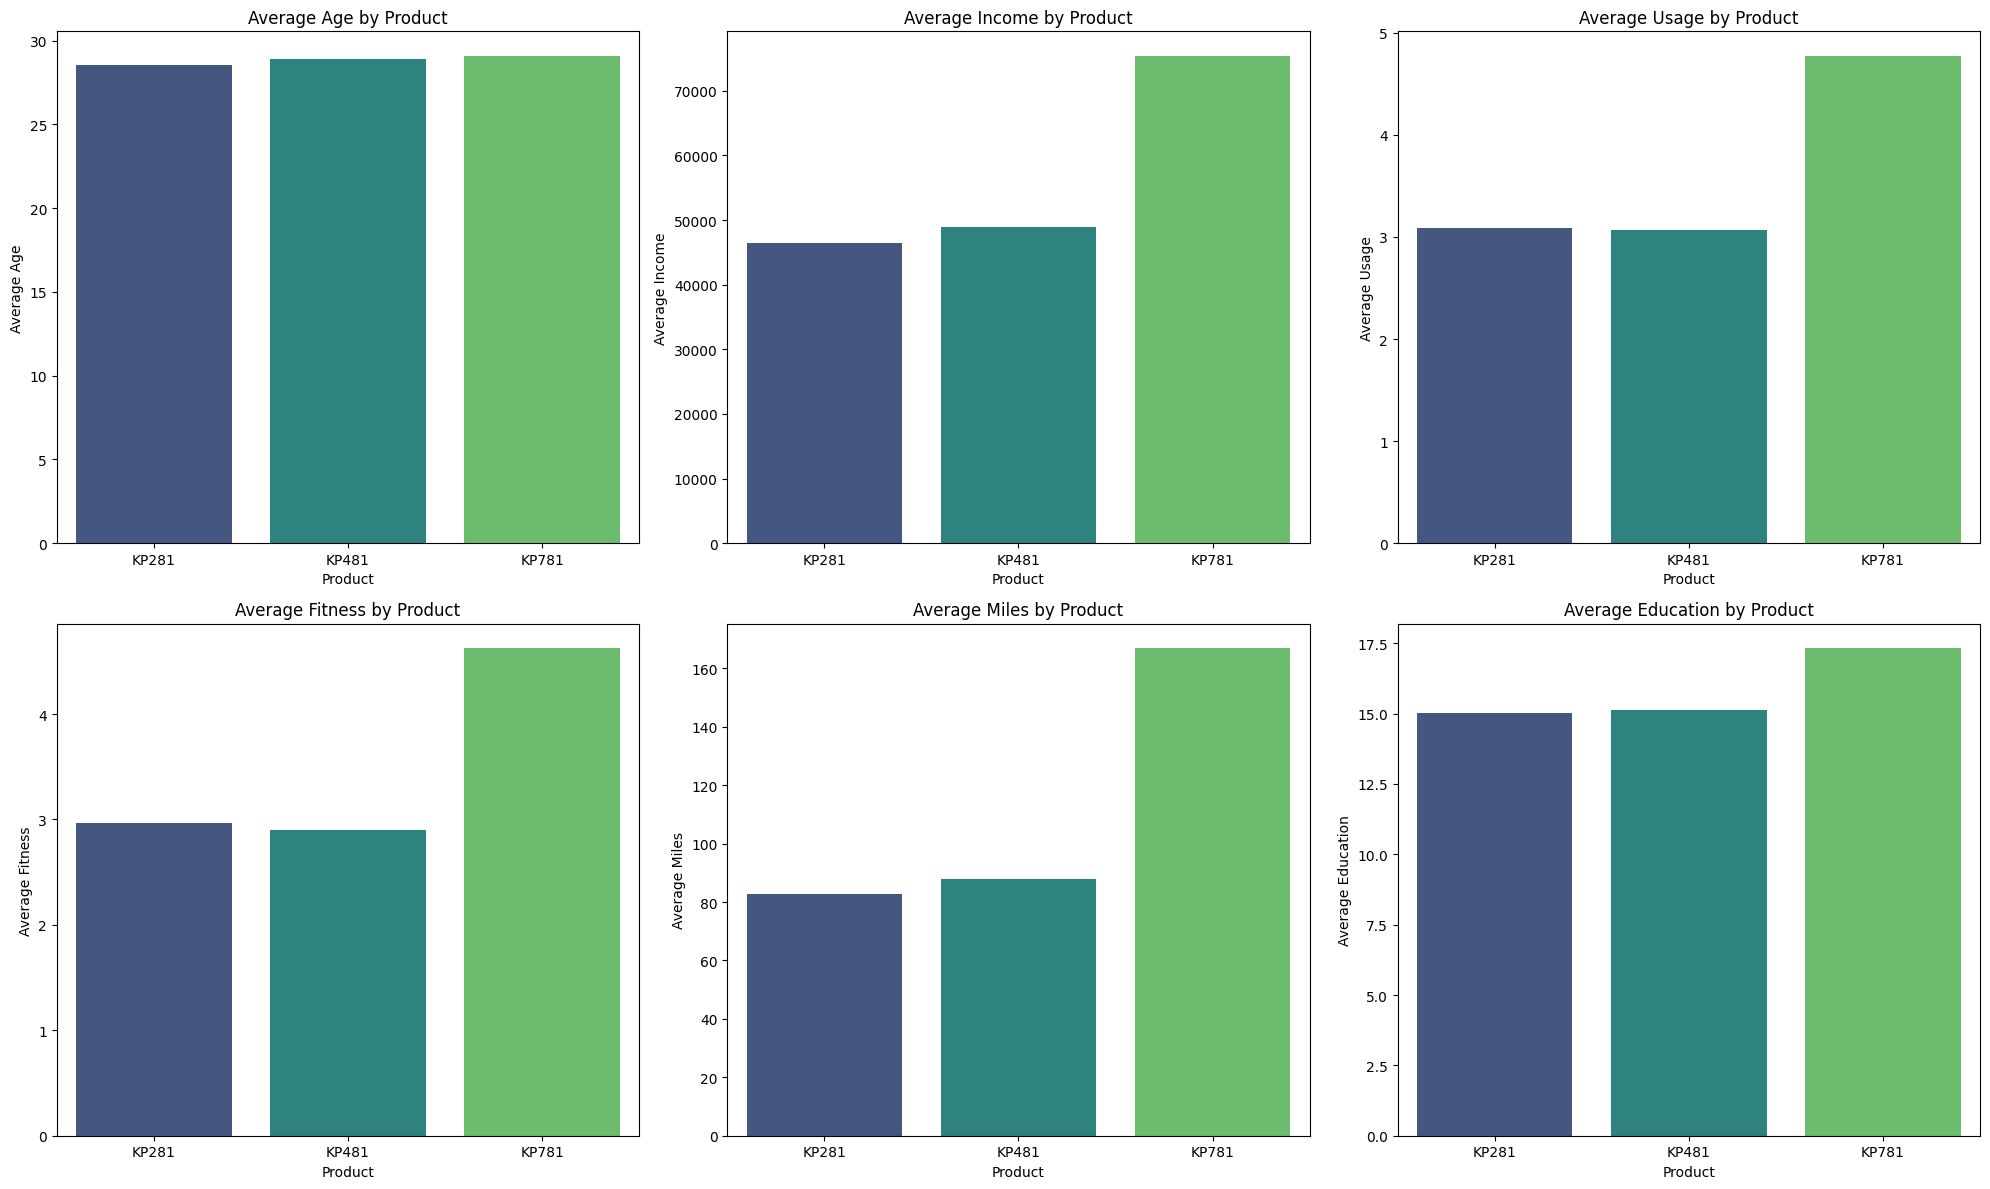

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure product_kpis DataFrame is available; if not, re-run the KPI calculation cell
# For robustness, we can re-create it here if it's not in the kernel state
# df was reloaded in the previous step, so it should be available
if 'product_kpis' not in locals() and 'product_kpis' not in globals():
    product_kpis = df.groupby('Product')[['Age', 'Income', 'Usage', 'Fitness', 'Miles', 'Education']].mean()

kpi_columns = ['Age', 'Income', 'Usage', 'Fitness', 'Miles', 'Education']

# Set up the matplotlib figure and axes for 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten() # Flatten the 2x3 array of axes for easier iteration

for i, col in enumerate(kpi_columns):
    sns.barplot(x=product_kpis.index, y=product_kpis[col], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Average {col} by Product')
    axes[i].set_xlabel('Product')
    axes[i].set_ylabel(f'Average {col}')

plt.tight_layout()
plt.show()


## Visual Analysis - Pie Charts for Categorical Distributions

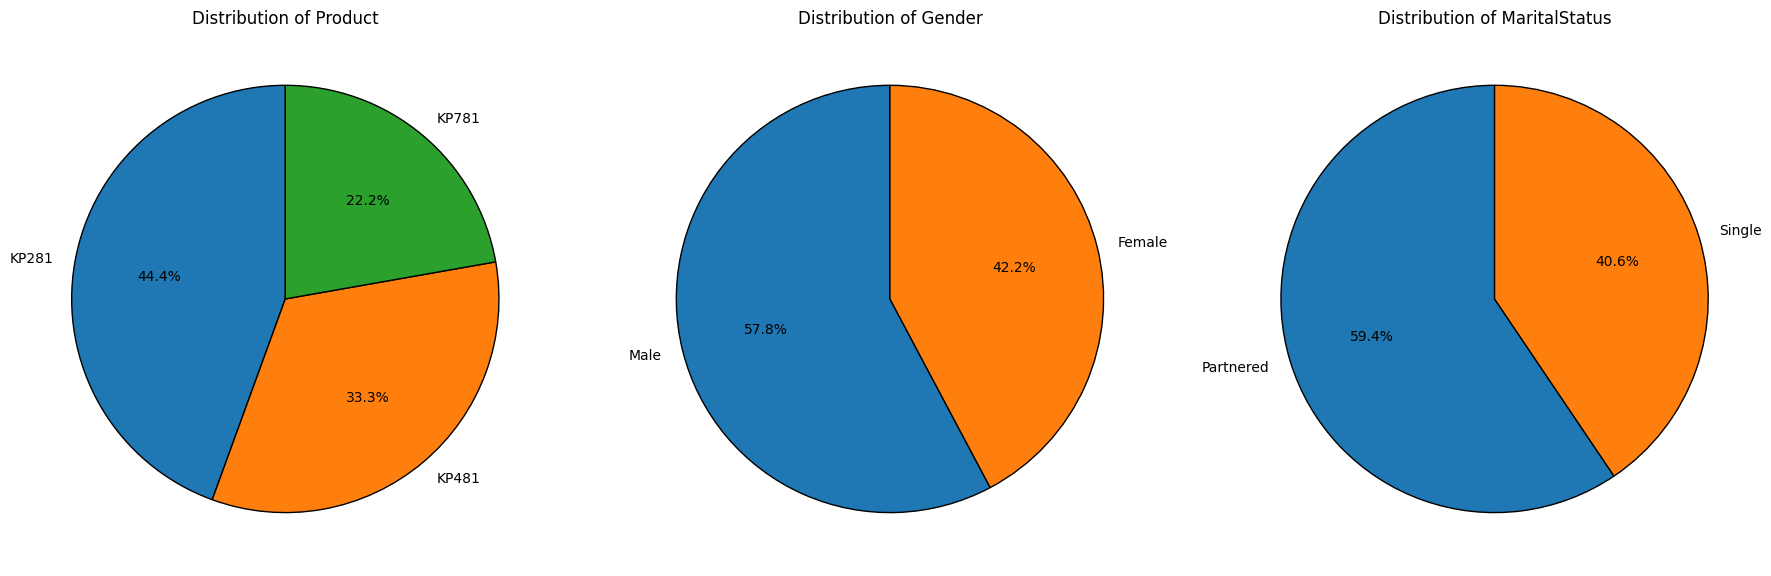

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['Product', 'Gender', 'MaritalStatus']

plt.figure(figsize=(18, 6))

for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    counts = df[col].value_counts()
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

###  Next Steps in terms of exploration can be:

*   **Targeted Marketing Strategies**: Given the strong gender preference for KP781, marketing efforts for this premium product should be heavily tailored towards male demographics, highlighting performance and advanced features. For KP281 and KP481, broader, more inclusive campaigns would be suitable.
*   **Product Development & Pricing**: The clear segmentation by income and expected usage suggests opportunities for Aerofit to further differentiate their product lines. Consider developing new models or feature packages that cater specifically to the high-income, high-usage segment, or exploring entry-level options that might appeal to an even wider casual user base.

## Data Preparation for Clustering


Selected relevant numerical features for clustering and scale them to ensure all features contribute equally to the clustering process.



Preparation of numerical features for clustering requires specified coloumns selection.



In [27]:
from sklearn.preprocessing import StandardScaler

# 2. Select the numerical features
numerical_features = ['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']
X = df[numerical_features]

# 3. Instantiate StandardScaler
scaler = StandardScaler()

# 4. Apply the scaler to the selected numerical features
X_scaled = scaler.fit_transform(X)

# 5. Convert the scaled data into a pandas DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=numerical_features)

# 6. Print the first 5 rows of X_scaled_df
print("Scaled Numerical Features (X_scaled_df.head()):\n")
print(X_scaled_df.head())

Scaled Numerical Features (X_scaled_df.head()):

        Age  Education     Usage   Fitness    Income     Miles
0 -1.558146  -0.974987 -0.421117  0.720443 -1.467585  0.170257
1 -1.413725  -0.354854 -1.345520 -0.325362 -1.329438 -0.545143
2 -1.413725  -0.974987  0.503286 -0.325362 -1.398512 -0.719159
3 -1.413725  -2.215254 -0.421117 -0.325362 -1.260365 -0.351792
4 -1.269303  -1.595120  0.503286 -1.371166 -1.122218 -1.086527


## Determining Optimal Number of Clusters

Methods like the Elbow Method or Silhouette Score is used to find the optimal number of clusters for the dataset.



To determine the optimal number of clusters, implementation of both the Elbow Method and Silhouette Score os done. This involves iterating through a range of possible cluster numbers, fitting KMeans models, and storing their inertia and silhouette scores. These metrics will then be visualized to identify the optimal number of clusters.



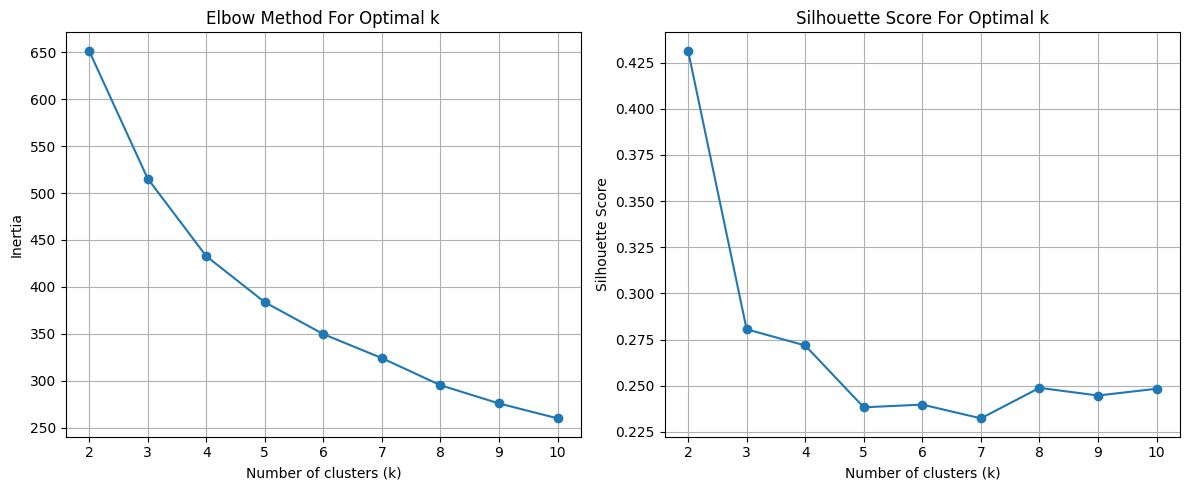


Optimal number of clusters based on Silhouette Score: 2


In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize lists to store inertia and silhouette scores
inertia = []
silhouette_scores = []

# Define a range for the number of clusters
k_range = range(2, 11) # Typically start from 2 clusters

for k in k_range:
    # Instantiate KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Set n_init to suppress warning

    # Fit the model to the scaled data
    kmeans.fit(X_scaled_df)

    # Store inertia (for Elbow Method)
    inertia.append(kmeans.inertia_)

    # Calculate and store silhouette score
    score = silhouette_score(X_scaled_df, kmeans.labels_)
    silhouette_scores.append(score)

# Plotting the Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)

# Plotting the Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Score For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

# Find the k with the highest silhouette score
optimal_k_silhouette = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nOptimal number of clusters based on Silhouette Score: {optimal_k_silhouette}")

## Application of Clustering Algorithm


Applied a clustering algorithm (e.g., K-Means) to the scaled data to group customers into distinct segments.


**Reasoning**:
To apply the K-Means clustering algorithm, I will instantiate KMeans with the optimal number of clusters found (2) and fit it to the scaled data. Then, I will add the resulting cluster labels to the original DataFrame for further analysis.



In [29]:
from sklearn.cluster import KMeans

# Instantiate KMeans model with the optimal number of clusters (2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

# Fit the KMeans model to the scaled data
kmeans.fit(X_scaled_df)

# Add the cluster labels to the original DataFrame
df['Cluster'] = kmeans.labels_

print("K-Means clustering applied and labels added to 'Cluster' column in original DataFrame.")
print(df[['Product', 'Age', 'Income', 'Cluster']].head())

K-Means clustering applied and labels added to 'Cluster' column in original DataFrame.
  Product  Age  Income  Cluster
0   KP281   18   29562        0
1   KP281   19   31836        0
2   KP281   19   30699        0
3   KP281   19   32973        0
4   KP281   20   35247        0


## Analysis and Visualisation of Clusters


Analyzed the characteristics of each cluster by examining the mean values of the original features within each segment. Visualized the clusters to understand their separation and features, including legends to differentiate clusters.


In [30]:
numerical_features = ['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']
cluster_centers_original_scale = df.groupby('Cluster')[numerical_features].mean()

print("Cluster Characteristics (Mean values in original scale):\n")
print(cluster_centers_original_scale.round(2))

Cluster Characteristics (Mean values in original scale):

           Age  Education  Usage  Fitness    Income   Miles
Cluster                                                    
0        28.46      15.08   3.07     2.93  47616.77   83.94
1        29.97      17.36   4.85     4.69  75783.56  172.79



To visualize the characteristics of each cluster, created bar plots for each numerical feature, showing the mean value per cluster. This will visually highlight how clusters differ across these attributes.



/tmp/ipython-input-3678266391.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_centers_original_scale.index, y=cluster_centers_original_scale[col], palette='viridis')
/tmp/ipython-input-3678266391.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_centers_original_scale.index, y=cluster_centers_original_scale[col], palette='viridis')
/tmp/ipython-input-3678266391.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_centers_original_scale.index, y=cluster_centers_original_scale[col], palette='viridis')
/tmp/ip

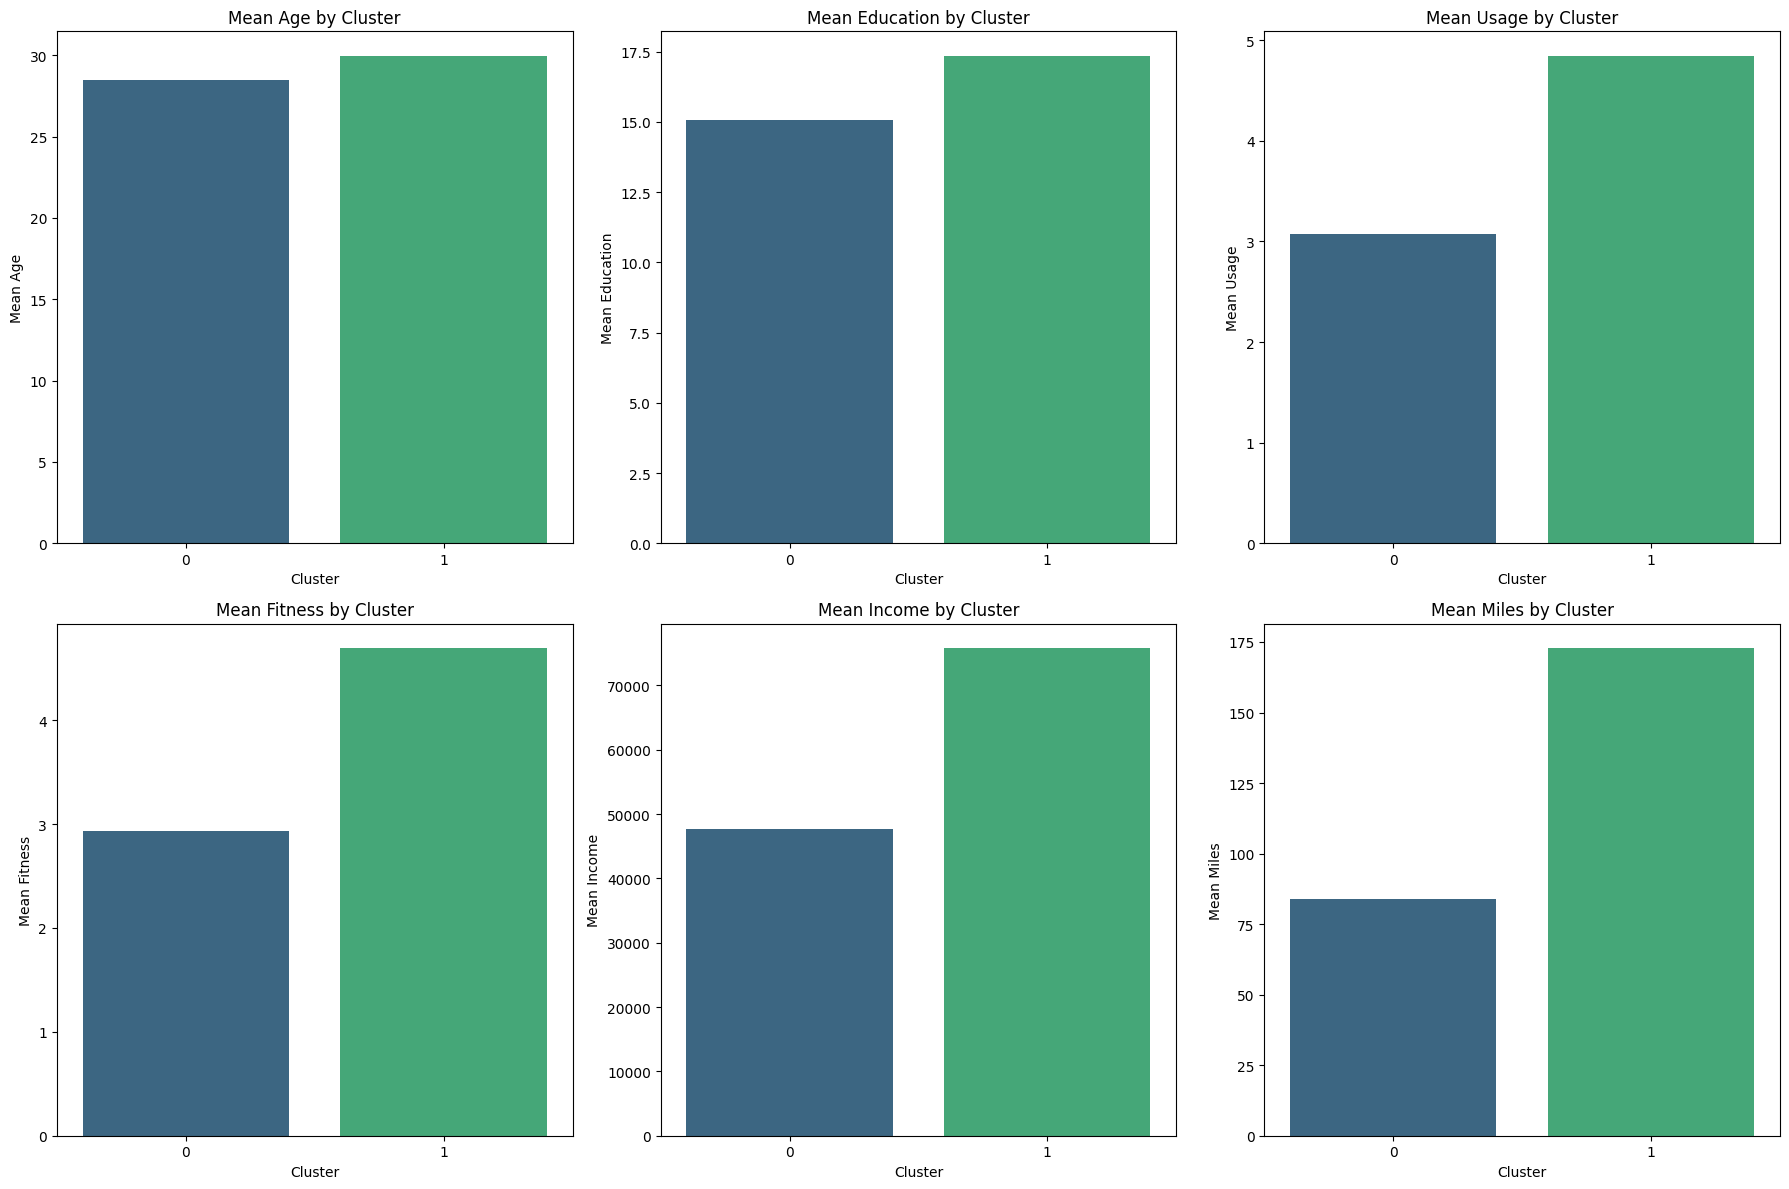

In [31]:
numerical_features = ['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']

plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.barplot(x=cluster_centers_original_scale.index, y=cluster_centers_original_scale[col], palette='viridis')
    plt.title(f'Mean {col} by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(f'Mean {col}')

plt.tight_layout()
plt.show()

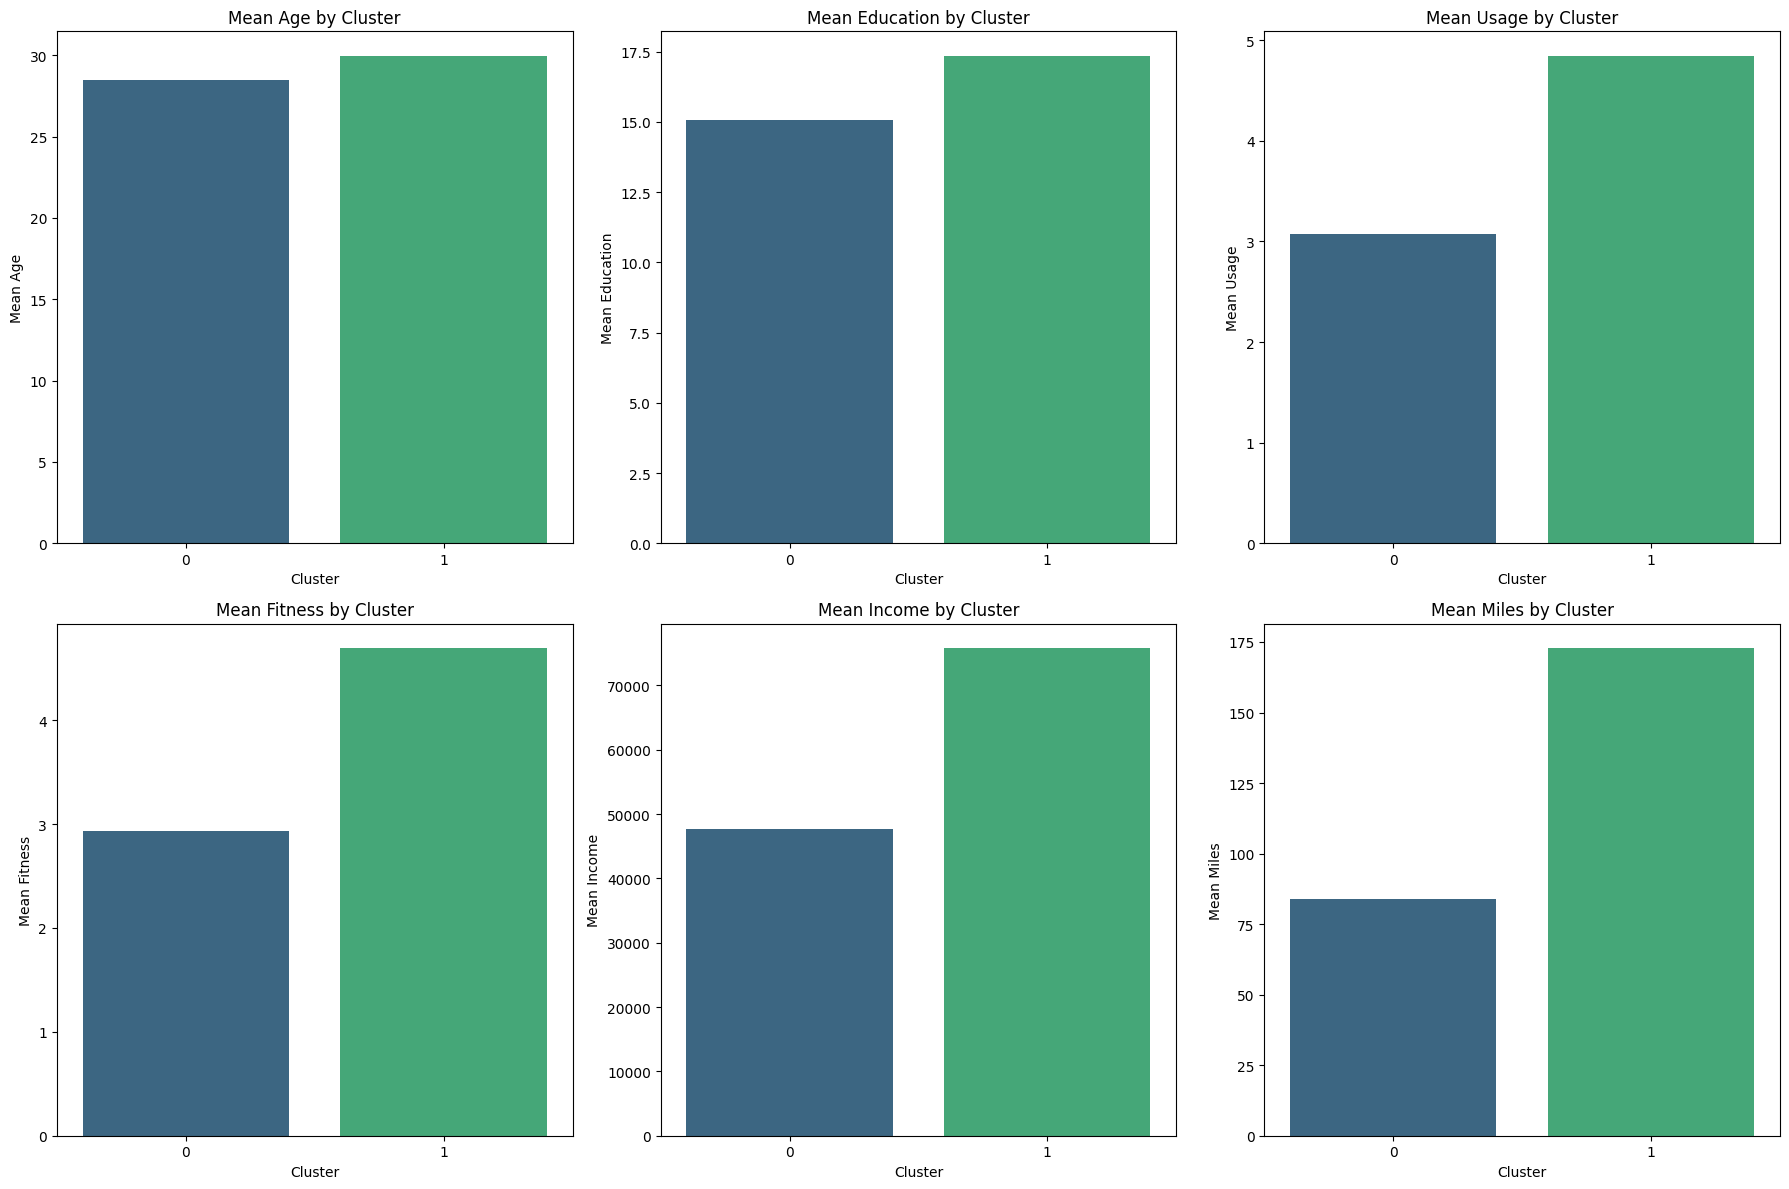

<Figure size 1200x1000 with 0 Axes>

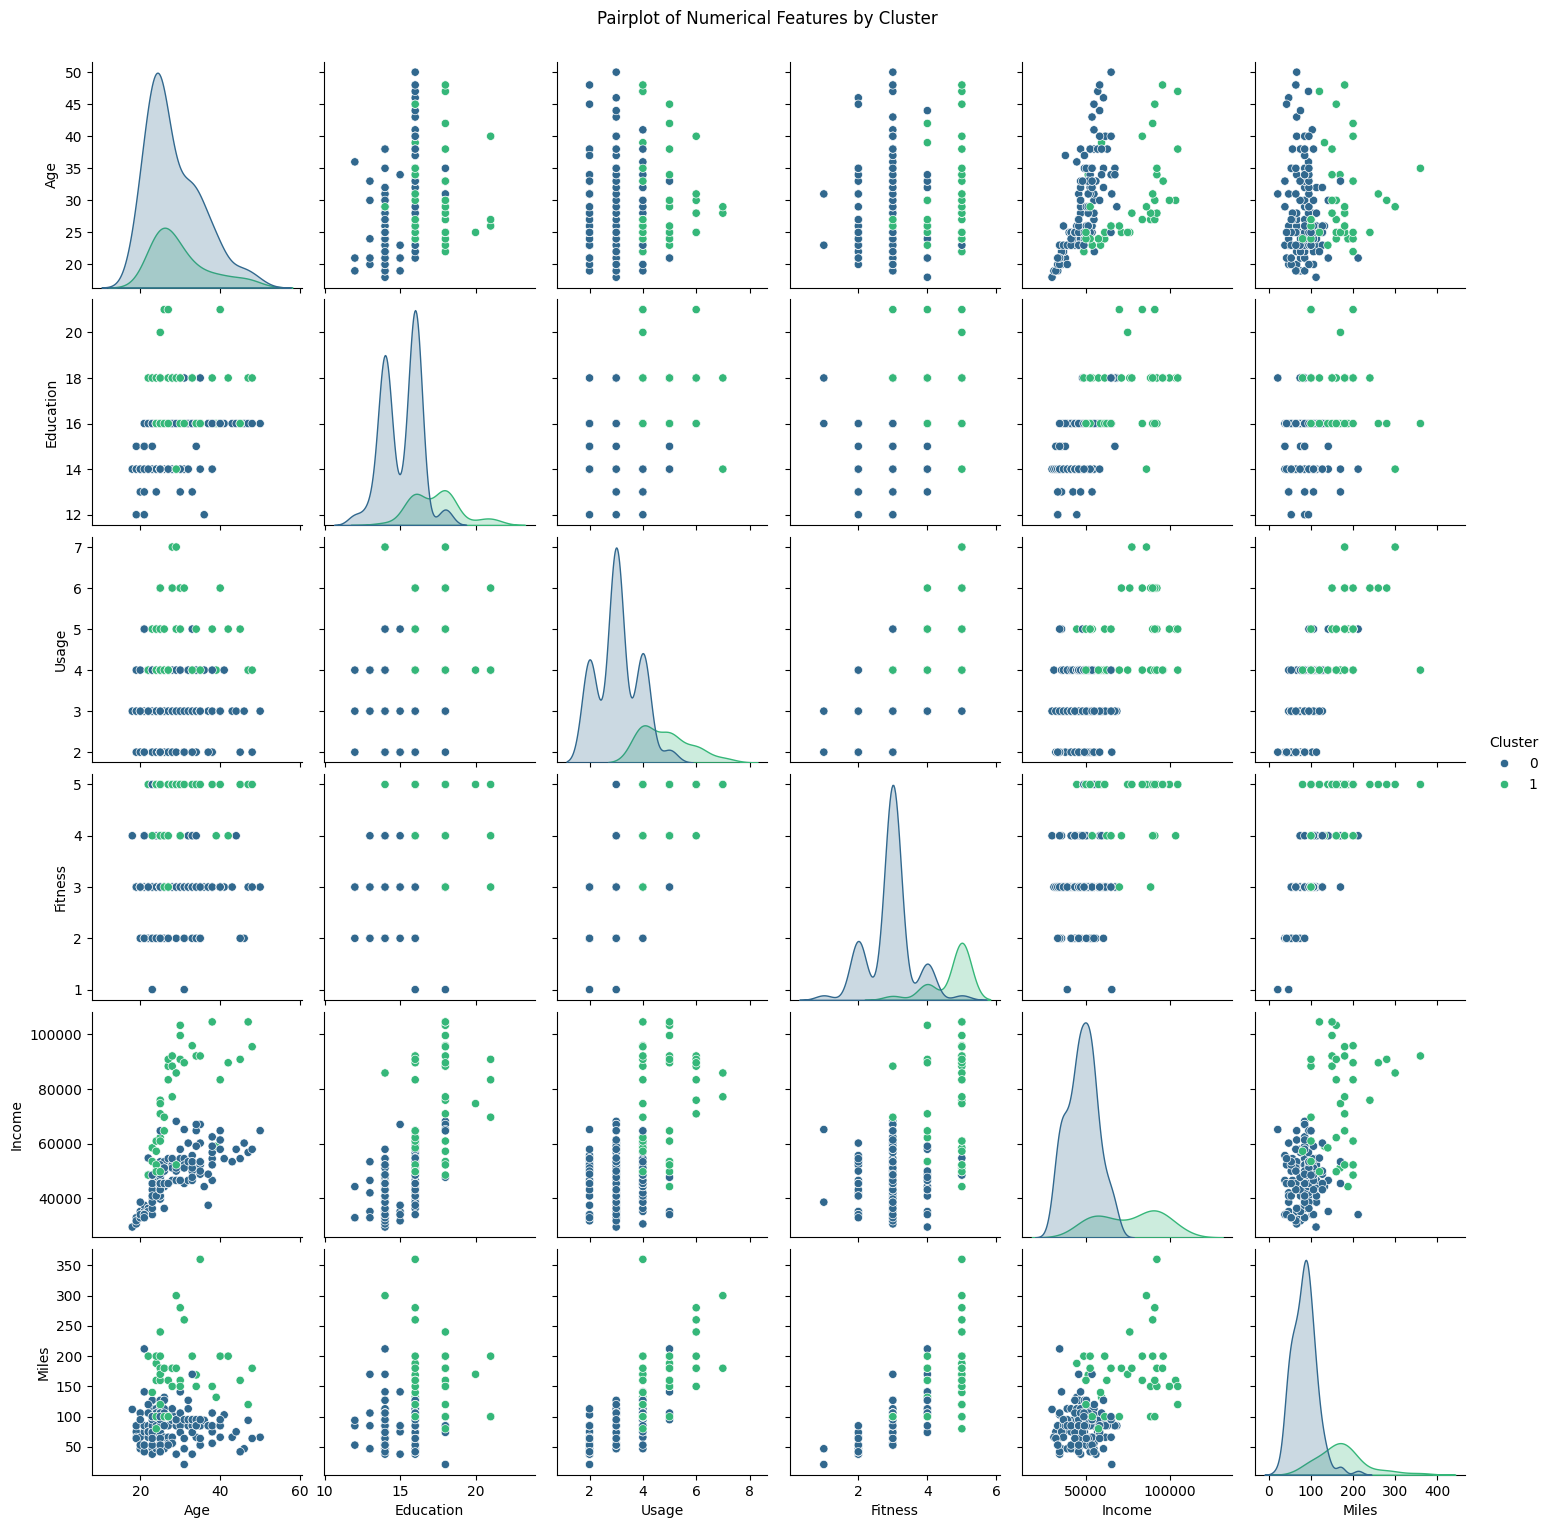

In [32]:
numerical_features = ['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']

plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.barplot(x=cluster_centers_original_scale.index, y=cluster_centers_original_scale[col], hue=cluster_centers_original_scale.index, palette='viridis', legend=False)
    plt.title(f'Mean {col} by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(f'Mean {col}')

plt.tight_layout()
plt.show()

# Create a pairplot of the original numerical features, coloring the points by their assigned 'Cluster' label.
# Ensure the pairplot includes a legend.
plt.figure(figsize=(12, 10))
sns.pairplot(df, vars=numerical_features, hue='Cluster', palette='viridis')
plt.suptitle('Pairplot of Numerical Features by Cluster', y=1.02) # Adjust suptitle position
plt.show()

## Summary:

### Data Analysis Key Findings

*   **Feature Scaling**: Six numerical features (`Age`, `Education`, `Usage`, `Fitness`, `Income`, `Miles`) were successfully selected and scaled using `StandardScaler`, ensuring all features contribute equally to the clustering process.
*   **Optimal Cluster Determination**:
    *   The Elbow Method for determining the optimal number of clusters showed an ambiguous "elbow."
    *   The Silhouette Score, however, clearly indicated that **2 clusters** provided the best separation and compactness, with the highest score achieved at k=2.
*   **Clustering Application**: K-Means clustering was applied to the scaled data, successfully segmenting customers into two distinct groups (Cluster 0 and Cluster 1).
*   **Cluster Characteristics**:
    *   **Cluster 0 (Less Engaged/Lower Income)**: This segment is characterized by younger individuals (mean age: 28.46 years), slightly lower education (mean: 15.08 years), lower product usage (mean: 3.07 times/week), lower fitness levels (mean: 2.93), lower average income (mean: \$47,616.77), and fewer miles covered (mean: 83.94 miles/week).
    *   **Cluster 1 (Highly Engaged/Higher Income)**: This segment consists of slightly older individuals (mean age: 29.97 years) with higher education (mean: 17.36 years), significantly higher product usage (mean: 4.85 times/week), higher fitness levels (mean: 4.69), considerably higher average income (mean: \$75,783.56), and more miles covered (mean: 172.79 miles/week).
*   **Cluster Visualization**: Visualizations, including bar plots and pairplots, confirmed the clear separation and distinct profiles of the two identified customer clusters based on their numerical features.

### Insights or Next Steps

*   The analysis reveals two distinct customer segments with clear differences in engagement, income, fitness, and usage patterns. This segmentation is crucial for developing targeted strategies.
*   Developed tailored marketing campaigns and product offerings for each cluster: For Cluster 0, focus is on engagement-driving initiatives or more accessible product tiers; for Cluster 1, consider premium offerings, loyalty programs, or advanced features that align with their higher engagement and income.


## Analysis of Product Distribution within Clusters

Need to calculate and visualize the distribution of 'Product' within each identified cluster to understand product preferences of different customer segments.

**Rationale**:
To understand product preferences within each cluster, created a crosstabulation of 'Cluster' and 'Product' and then normalized it across the clusters to get percentage distributions. This will reveal which products are more prevalent in 'Cluster 0' versus 'Cluster 1'.

Product Distribution within each Cluster (%):

Product  KP281  KP481  KP781
Cluster                     
0        54.61  42.55   2.84
1         7.69   0.00  92.31


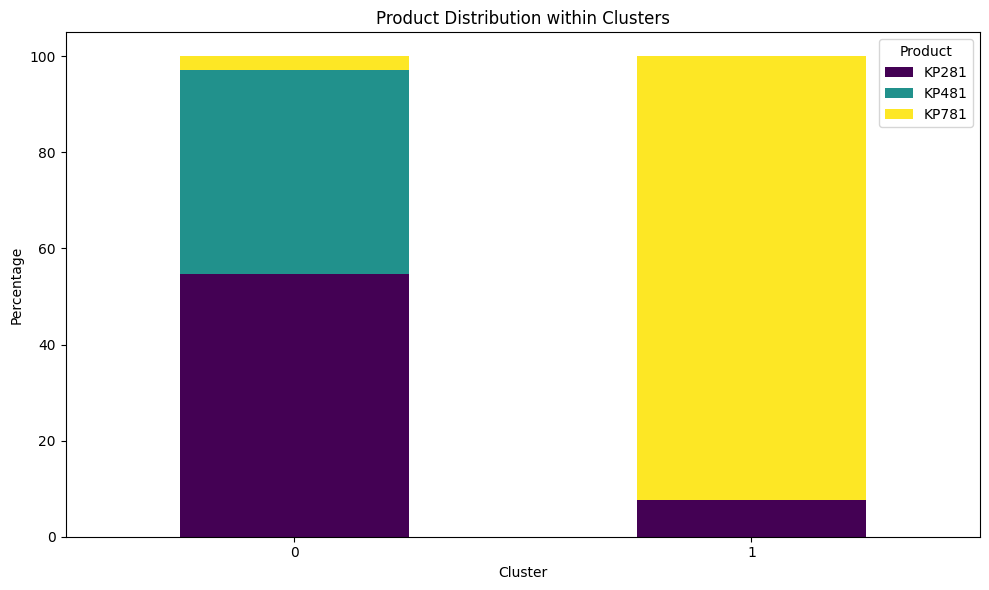

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the percentage distribution of products within each cluster
product_cluster_distribution = pd.crosstab(df['Cluster'], df['Product'], normalize='index') * 100

print("Product Distribution within each Cluster (%):\n")
print(product_cluster_distribution.round(2))

# Visualize the product distribution within clusters
product_cluster_distribution.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Product Distribution within Clusters')
plt.xlabel('Cluster')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Product')
plt.tight_layout()
plt.show()


This extensive analysis of the Aerofit treadmill dataset has successfully unearthed crucial insights into customer behavior and product segmentation. We began with a thorough examination of data characteristics, confirming data completeness and identifying initial trends in numerical and categorical features. Univariate and bivariate visual analyses further revealed distributions and relationships, highlighting distinctions in age, income, usage, and miles across product lines. The calculation of Key Performance Indicators (KPIs) quantified these differences, particularly showcasing the premium positioning of the KP781 model.

Crucially, our customer segmentation using K-Means clustering identified two distinct customer groups:

Cluster 0 (Less Engaged/Lower Income): Primarily comprising individuals with lower average incomes, usage, fitness levels, and miles, showing a strong preference for the entry-level KP281 and mid-range KP481 models.
Cluster 1 (Highly Engaged/Higher Income): Characterized by significantly higher average incomes, usage, fitness levels, and miles, almost exclusively purchasing the premium KP781 model.
This robust segmentation confirms that Aerofit successfully caters to diverse customer needs across its product range. The insights derived, from demographic preferences to product-specific engagement patterns, provide a solid foundation for targeted marketing strategies, product development, and customer engagement initiatives, ensuring Aerofit can effectively serve and grow its varied customer base."

# THANK YOU!!!